# Kaggle's Titanic Competition

This notebook explores the Titanic Dataset. The training data will be analysed to create a model that predicts whether passengers survive or not based off a number of features. This model will then be used on a test dataset, to predict the survivability of passengers.

The goal of this notebook is to have a clean, complete workflow for creating and validating the ML model. This includes EDA, feature engineering, pipeline, submit, and pushed to GitHub. 

## 1. EDA

Load data, check columns, check nulls, plot distribution with matplotlib

In [79]:
# Import Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Set Up Complete")

# Load Data
titanic = pd.read_csv("train.csv")
titanic.head(20)

Set Up Complete


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [80]:
# Info on Data
titanic.shape
titanic.info()

# Find missing values
titanic.isnull().sum()

# Explore columns 'PassengerID', 'Name', 'Ticket Number'
titanic['PassengerId'].nunique()
titanic['Name'].nunique()
titanic['Ticket'].nunique()

# Explore column 'Cabin' and how they differ for each Pclass
titanic.loc[titanic.Cabin.isnull()]
titanic.loc[(titanic.Cabin.notnull()) & (titanic.Pclass == 3)]

# Explore column 'Embarked'
titanic.Embarked.value_counts()
titanic[pd.isnull(titanic.Embarked)]
titanic.loc[(titanic.Ticket == "113572")]

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


<Figure size 1400x600 with 0 Axes>

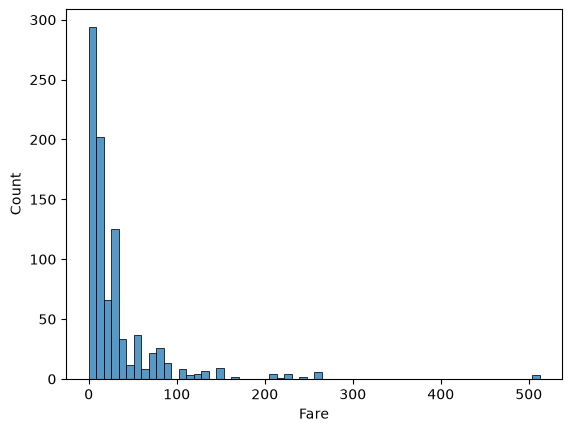

<Figure size 1400x600 with 0 Axes>

In [83]:
# Explore Pclass - check that values are either 1, 2, or 3
titanic.Pclass.value_counts()

# Explore Sex - check that values are either male or female
titanic.Sex.value_counts()

# Explore Age - check that within physiological range
titanic.Age.describe() #Range between 0.42 to 80 years old
titanic.loc[(titanic.Age < 1)] #All passengers below 1 survived.

# Explore SibSp and Parch
titanic.SibSp.value_counts()
titanic.Parch.value_counts()

# Explore Fare and visualise it using a histogram
titanic.Fare.describe()
sns.histplot(titanic['Fare'])
plt.figure(figsize=(14,6))

/Users/hweeenheah/Downloads/EDA_Resources/titanic-ml-pipeline/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 25.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/hweeenheah/Downloads/EDA_Resources/titanic-ml-pipeline/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 59.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Pclass', ylabel='Fare'>

/Users/hweeenheah/Downloads/EDA_Resources/titanic-ml-pipeline/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 35.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/hweeenheah/Downloads/EDA_Resources/titanic-ml-pipeline/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 63.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


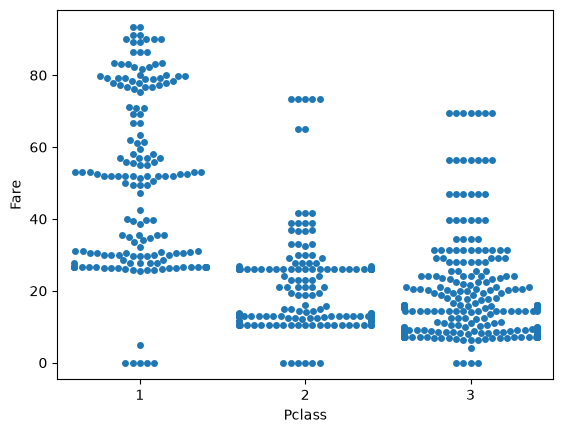

In [94]:
# Examine passengers with Fare = 0
titanic.loc[(titanic.Fare == 0)]

# Examine passengers with Fare > 300
titanic.loc[(titanic.Fare > 250)]

# Examine how Fare is related to Pclass
filtered_titanic = titanic[titanic["Fare"] < 100]
sns.swarmplot(x=filtered_titanic['Pclass'], y=filtered_titanic['Fare'])


### Plan to deal with each variable

1. Passenger ID - an identifier, not predictor. To drop.
2. Survived - the target, not predictor. To separate. 
3. Pclass - categorical variable (1, 2, or 3). Encode and use in model
4. Name - an identifier, not predictor. To drop.
5. Sex - binary (male or female). Encode to 0/1, and use in model
6. Age - numerical. To use in model
7. Sibsp - numerical. To use in model
8. Parch - numerical. To use in model
9. Ticket - ticket number an identifier, not predictor. To drop
10. Fare - Numerical (float). Fare = 0 exists. Fare 75th percentile = 31, but max = 512.3292. 
11. Cabin - Prefix appears to affect Pclass. But for the first analysis, we will drop this.
12. Embarked - categorical variable. To check that all values are either C, Q, or S. 2 Null values will be imputed using mode (most frequent).


## 2. Feature Engineering

1. Drop Passenger ID, Name, Ticket, and Cabin
2. Split training/validation data

In [121]:
# Drop Passenger ID, Name, Ticket, Cabin
titanic_v2 = titanic.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Train/Test Split
from sklearn.model_selection import train_test_split
X = titanic_v2.drop(columns=["Survived"])
y = titanic_v2["Survived"]
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Pipeline

Impute numerical columns using median.
Impute categorical columnds using mode, and One Hot Encode it

Wrap preprocessing + Logistic Regression into a sklearn pipeline

In [143]:
# Separate numerical and categorical columns
numerical_columns = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_columns = ["Sex", "Embarked"]

# Import necessary libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Build preprocessing
numerical_transformer = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                    ("encoder", OneHotEncoder())])

# Combine both
preprocessing = ColumnTransformer([("num", numerical_transformer, numerical_columns),
                                   ("cat", categorical_transformer, categorical_columns)],
                                   remainder = 'passthrough')

# Add Logistic Regression
from sklearn.linear_model import LogisticRegression
model = Pipeline([("preprocessing", preprocessing),
                  ("classifier", LogisticRegression(max_iter=1000))])

# Train
model.fit(X_train, y_train)

# Evaluate
model.score(X_valid, y_valid)

# See model's predictions
y_pred = model.predict(X_valid)
results = pd.DataFrame({"Actual": y_valid, "Predicted": y_pred})
results.head(20)

,Actual,Predicted
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


The initial Logistic Regression tried up to 100 iterations, but hadn't converged by then. With a validation accuracy of 0.8044, my initial Logistic Regression model correctly predicted about 80.44% of the validation passengers. 

Increasing the number of iterations to 1000, the Logistic Regression optimization converged before reaching the 1000-iteration limit. It now has validation accuracy of 0.81005, indicating that the converged model correctly predicted about 81.01% of the validation passengers. 

## 4. Submit

Generate predictions on test set, to csv, submit csv to Kaggle